In [1]:
!mamba install pandas numpy matplotlib scikit-learn seaborn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn, seaborn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 5.363599999904633 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.2.25                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.5                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.11                          pyhd8ed1ab_0                  conda-forge                   
+ joblib                     

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split

In [3]:
import os
os.listdir()

['Salary_dataset.csv',
 'Student_Performance.csv',
 'Untitled.ipynb',
 'prediction.csv',
 'study_performance.ipynb',
 'sqlite.ipynb',
 'r.ipynb',
 'Intro.ipynb',
 'cpp-smallpt.ipynb',
 'cpp-third-party-libs.ipynb',
 'cpp.ipynb',
 'Lorenz.ipynb']

In [7]:
df = pd.read_csv('Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [8]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='str')

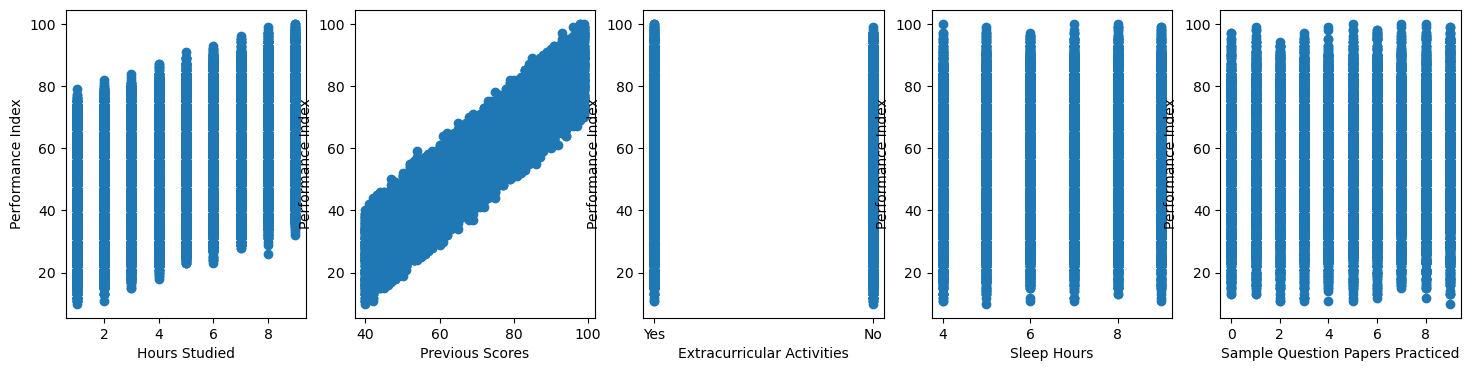

In [16]:
plt.figure(figsize = (18,4))

plt.subplot(1,5,1)
plt.scatter(df['Hours Studied'], df['Performance Index'])
plt.xlabel('Hours Studied')
plt.ylabel('Performance Index')
plt.grid(False)

plt.subplot(1,5,2)
plt.scatter(df['Previous Scores'], df['Performance Index'])
plt.xlabel('Previous Scores')
plt.ylabel('Performance Index')
plt.grid(False)

plt.subplot(1,5,3)
plt.scatter(df['Extracurricular Activities'], df['Performance Index'])
plt.xlabel('Extracurricular Activities')
plt.ylabel('Performance Index')
plt.grid(False)

plt.subplot(1,5,4)
plt.scatter(df['Sleep Hours'], df['Performance Index'])
plt.xlabel('Sleep Hours')
plt.ylabel('Performance Index')
plt.grid(False)

plt.subplot(1,5,5)
plt.scatter(df['Sample Question Papers Practiced'], df['Performance Index'])
plt.xlabel('Sample Question Papers Practiced')
plt.ylabel('Performance Index')
plt.grid(False)

plt.show()

In [20]:
#Hours studied show positive linear relation and Previous score shows very strong linear relation

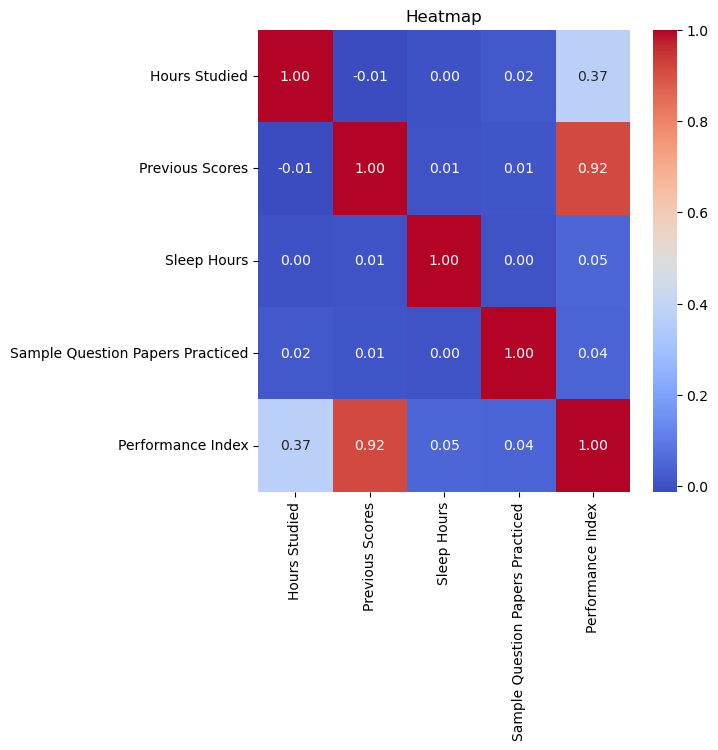

In [19]:
plt.figure(figsize = (6,6))

corr = df.corr(numeric_only = True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap')
plt.show()

In [22]:
X = df[['Hours Studied', 'Previous Scores']]
y = df['Performance Index']

In [23]:
X.head(5)

,Hours Studied,Previous Scores
0,7,99
1,4,82
2,8,51
3,5,52
4,7,75


In [24]:
y.head(5)

0    91.0
1    65.0
2    45.0
3    36.0
4    66.0
Name: Performance Index, dtype: float64

In [25]:
X.size

20000

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25)

In [27]:
X_train.head(5)

,Hours Studied,Previous Scores
5563,8,52
8618,1,80
9333,3,55
5326,2,40
3693,2,77


In [28]:
X_test.head(5)

,Hours Studied,Previous Scores
3893,5,44
7690,2,76
5374,3,52
2504,4,48
6367,9,76


In [29]:
y_test.head(5)

3893    33.0
7690    54.0
5374    32.0
2504    34.0
6367    71.0
Name: Performance Index, dtype: float64

In [31]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
lr.predict(X_test)

array([29.33050355, 53.35508761, 31.76558901, ..., 62.32352282,
       73.94986154, 42.99403785], shape=(2500,))